# Phase 4: Decision Tree — EPC Energy Score Prediction

This notebook implements the **symbolic model** component of our modeling pipeline.

**Task:** Regression — predict `CURRENT_ENERGY_EFFICIENCY` (1–147 scale) from physical building characteristics only.

**Post-prediction binning:** Predicted score ≥ 69 → Efficient (A–C), < 69 → Inefficient (D–G)

### Notebook structure
1. Setup & Data Load
2. Define Features & Target
3. Train / Test Split
4. Preprocessing Pipeline
5. Baseline (Dummy Regressor)
6. Decision Tree — Default
7. Hyperparameter Tuning (GridSearchCV)
8. Tree Visualization (shallow, interpretable)
9. Feature Importance
10. Summary

## 1. Setup & Data Load

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor

# Load Phase 3 output
df = pd.read_parquet('manchester_epc_phase3_final.parquet')

print(f"Dataset shape: {df.shape}")
print(f"\nTarget — CURRENT_ENERGY_EFFICIENCY:")
print(df['CURRENT_ENERGY_EFFICIENCY'].describe())

Dataset shape: (266470, 75)

Target — CURRENT_ENERGY_EFFICIENCY:
count    266470.000000
mean         68.935618
std          11.645365
min           1.000000
25%          63.000000
50%          70.000000
75%          77.000000
max         147.000000
Name: CURRENT_ENERGY_EFFICIENCY, dtype: float64


## 2. Define Features & Target

`CURRENT_ENERGY_EFFICIENCY` is our regression target.
`target_is_efficient` is excluded from features (it is derived from the target) and kept only for post-prediction evaluation.

Total features  : 73
  Numeric       : 73
  Categorical   : 0

Target range    : 1 - 147  |  mean: 68.9  |  std: 11.6


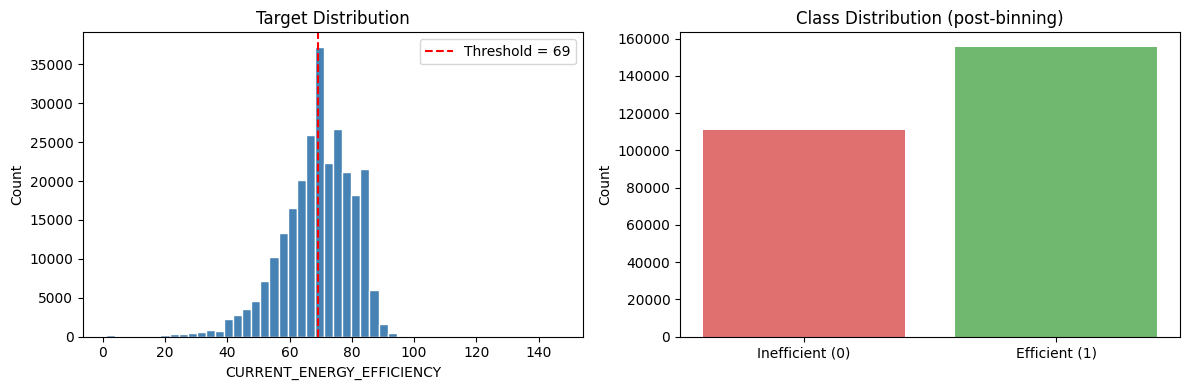

In [130]:
TARGET = 'CURRENT_ENERGY_EFFICIENCY'
BINNING_LABEL = 'target_is_efficient'   # used for distribution plot and post-prediction eval (combined notebook)
THRESHOLD = 69                          # EPC band C/D boundary: UK govt 2030 rental target requires band C (≥69) or above

# Features = all columns except target and its direct derivative
EXCLUDE = [TARGET, BINNING_LABEL]
feature_cols = [c for c in df.columns if c not in EXCLUDE]

X = df[feature_cols]
y = df[TARGET]

# Separate dtype groups for pipeline
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Total features  : {X.shape[1]}")
print(f"  Numeric       : {len(numeric_cols)}")
print(f"  Categorical   : {len(categorical_cols)}")
print(f"\nTarget range    : {y.min()} - {y.max()}  |  mean: {y.mean():.1f}  |  std: {y.std():.1f}")

# Target distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(THRESHOLD, color='red', linestyle='--', label=f'Threshold = {THRESHOLD}')
axes[0].set_xlabel('CURRENT_ENERGY_EFFICIENCY')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution')
axes[0].legend()

class_counts = df[BINNING_LABEL].value_counts()
axes[1].bar(['Inefficient (0)', 'Efficient (1)'],
            [class_counts.get(0, 0), class_counts.get(1, 0)],
            color=['#e07070', '#70b870'])
axes[1].set_title('Class Distribution (post-binning)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Train / Test Split

80/20 split. The test set is held out and only used once for final evaluation — never during model selection or hyperparameter tuning.

In [131]:
#x_test and y_test are saved here for use in the combined evaluation notebook.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set : {X_train.shape[0]:,} rows")
print(f"Test set  : {X_test.shape[0]:,} rows")

Train set : 213,176 rows
Test set  : 53,294 rows


## 4. Preprocessing Pipeline

All transformations that learn from data (imputation, encoding) are wrapped inside a sklearn `Pipeline`. This ensures they are fitted **only on training folds** during cross-validation, preventing any data leakage.

In [132]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Note: after Phase 3 preprocessing, all remaining features are numeric
# The categorical branch of the pipeline is defined for robustness but applies to zero columns in this dataset.
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
], remainder='drop') # explicitly drop any unspecified columns to avoid accidental inclusion

print("Preprocessor defined — numeric: median imputation | categorical: 'Unknown' fill + OHE")

Preprocessor defined — numeric: median imputation | categorical: 'Unknown' fill + OHE


## 5. Baseline — Dummy Regressor

The baseline always predicts the **mean** of the training target. Any meaningful model should beat this.

In [133]:
dummy_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyRegressor(strategy='median'))
])

# sklearn maximises scores internally, so RMSE is returned as negative — negate to read as positive
dummy_cv_rmse = cross_val_score(
    dummy_pipeline, X_train, y_train,
    cv=10, scoring='neg_root_mean_squared_error', n_jobs=-1
)
dummy_cv_mae = cross_val_score(
    dummy_pipeline, X_train, y_train,
    cv=10, scoring='neg_mean_absolute_error', n_jobs=-1
)

print("=== BASELINE (Dummy Regressor — predict mean) ===")
print(f"CV RMSE : {-dummy_cv_rmse.mean():.3f} ± {dummy_cv_rmse.std():.3f}")
print(f"CV MAE  : {-dummy_cv_mae.mean():.3f} ± {dummy_cv_mae.std():.3f}")

=== BASELINE (Dummy Regressor — predict mean) ===
CV RMSE : 11.697 ± 0.082
CV MAE  : 8.716 ± 0.046


## 6. Decision Tree — Default (untuned)

Establishing cross-validated performance of an out-of-the-box Decision Tree Regressor before hyperparameter tuning.

In [134]:
dt_default_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

dt_default_rmse = cross_val_score(
    dt_default_pipeline, X_train, y_train,
    cv=10, scoring='neg_root_mean_squared_error', n_jobs=-1
)
dt_default_mae = cross_val_score(
    dt_default_pipeline, X_train, y_train,
    cv=10, scoring='neg_mean_absolute_error', n_jobs=-1
)

print("=== DEFAULT DECISION TREE ===")
print(f"CV RMSE : {-dt_default_rmse.mean():.3f} ± {dt_default_rmse.std():.3f}")
print(f"CV MAE  : {-dt_default_mae.mean():.3f} ± {dt_default_mae.std():.3f}")
print(f"\nImprovement over baseline RMSE: {(-dummy_cv_rmse.mean() - (-dt_default_rmse.mean())):.3f}")

=== DEFAULT DECISION TREE ===
CV RMSE : 7.128 ± 0.072
CV MAE  : 4.629 ± 0.037

Improvement over baseline RMSE: 4.569


## 7. Hyperparameter Tuning — GridSearchCV

We search over `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_features`. 
5-fold CV on the training set only. Primary metric: RMSE.

In [135]:
dt_tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

param_grid = {
    'model__max_depth'        : [20],   # controls overfitting; None = unlimited
    'model__min_samples_split': [100],             # min samples to attempt a split
    'model__min_samples_leaf' : [10],              # min samples in a leaf; larger = smoother tree
    'model__max_features'     : [None]    # feature subsampling per split; reduces overfitting
}

grid_search = GridSearchCV(
    dt_tuning_pipeline,
    param_grid,
    cv=10,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train, y_train)

print("\n=== GRID SEARCH RESULTS ===")
print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV RMSE    : {-grid_search.best_score_:.3f}")

Fitting 10 folds for each of 1 candidates, totalling 10 fits

=== GRID SEARCH RESULTS ===
Best parameters : {'model__max_depth': 20, 'model__max_features': None, 'model__min_samples_leaf': 10, 'model__min_samples_split': 100}
Best CV RMSE    : 6.055


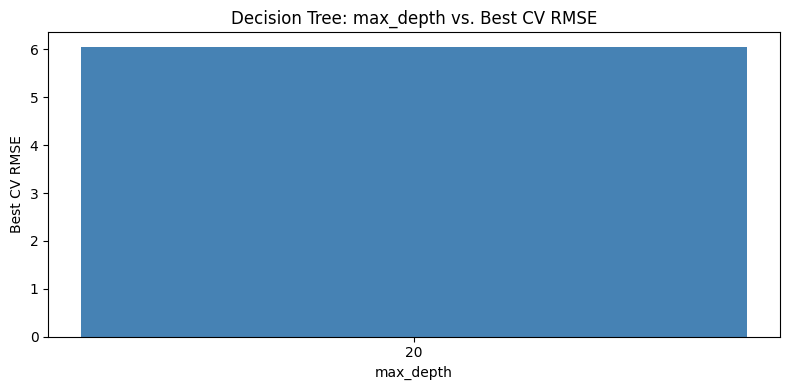

In [136]:
# Visualise depth vs. RMSE to understand overfitting behaviour
results_df = pd.DataFrame(grid_search.cv_results_)

depth_summary = (
    results_df
    .groupby('param_model__max_depth')['mean_test_score']
    .max()  # same depth has multiple param combos — take the best score among them
    .apply(lambda x: -x)   # back to positive RMSE
    .reset_index()
)
depth_summary.columns = ['max_depth', 'best_rmse_for_depth']
# Replace None with a label string for plotting
depth_summary['max_depth'] = depth_summary['max_depth'].astype(str)

plt.figure(figsize=(8, 4))
plt.bar(depth_summary['max_depth'], depth_summary['best_rmse_for_depth'], color='steelblue')
plt.xlabel('max_depth')
plt.ylabel('Best CV RMSE')
plt.title('Decision Tree: max_depth vs. Best CV RMSE')
plt.tight_layout()
plt.savefig('dt_depth_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Tree Visualization (interpretable, max_depth=4)

A shallow decision tree (max_depth=4) is trained separately to produce a **human-readable** decision structure. This is the symbolic model the report can describe and interpret.

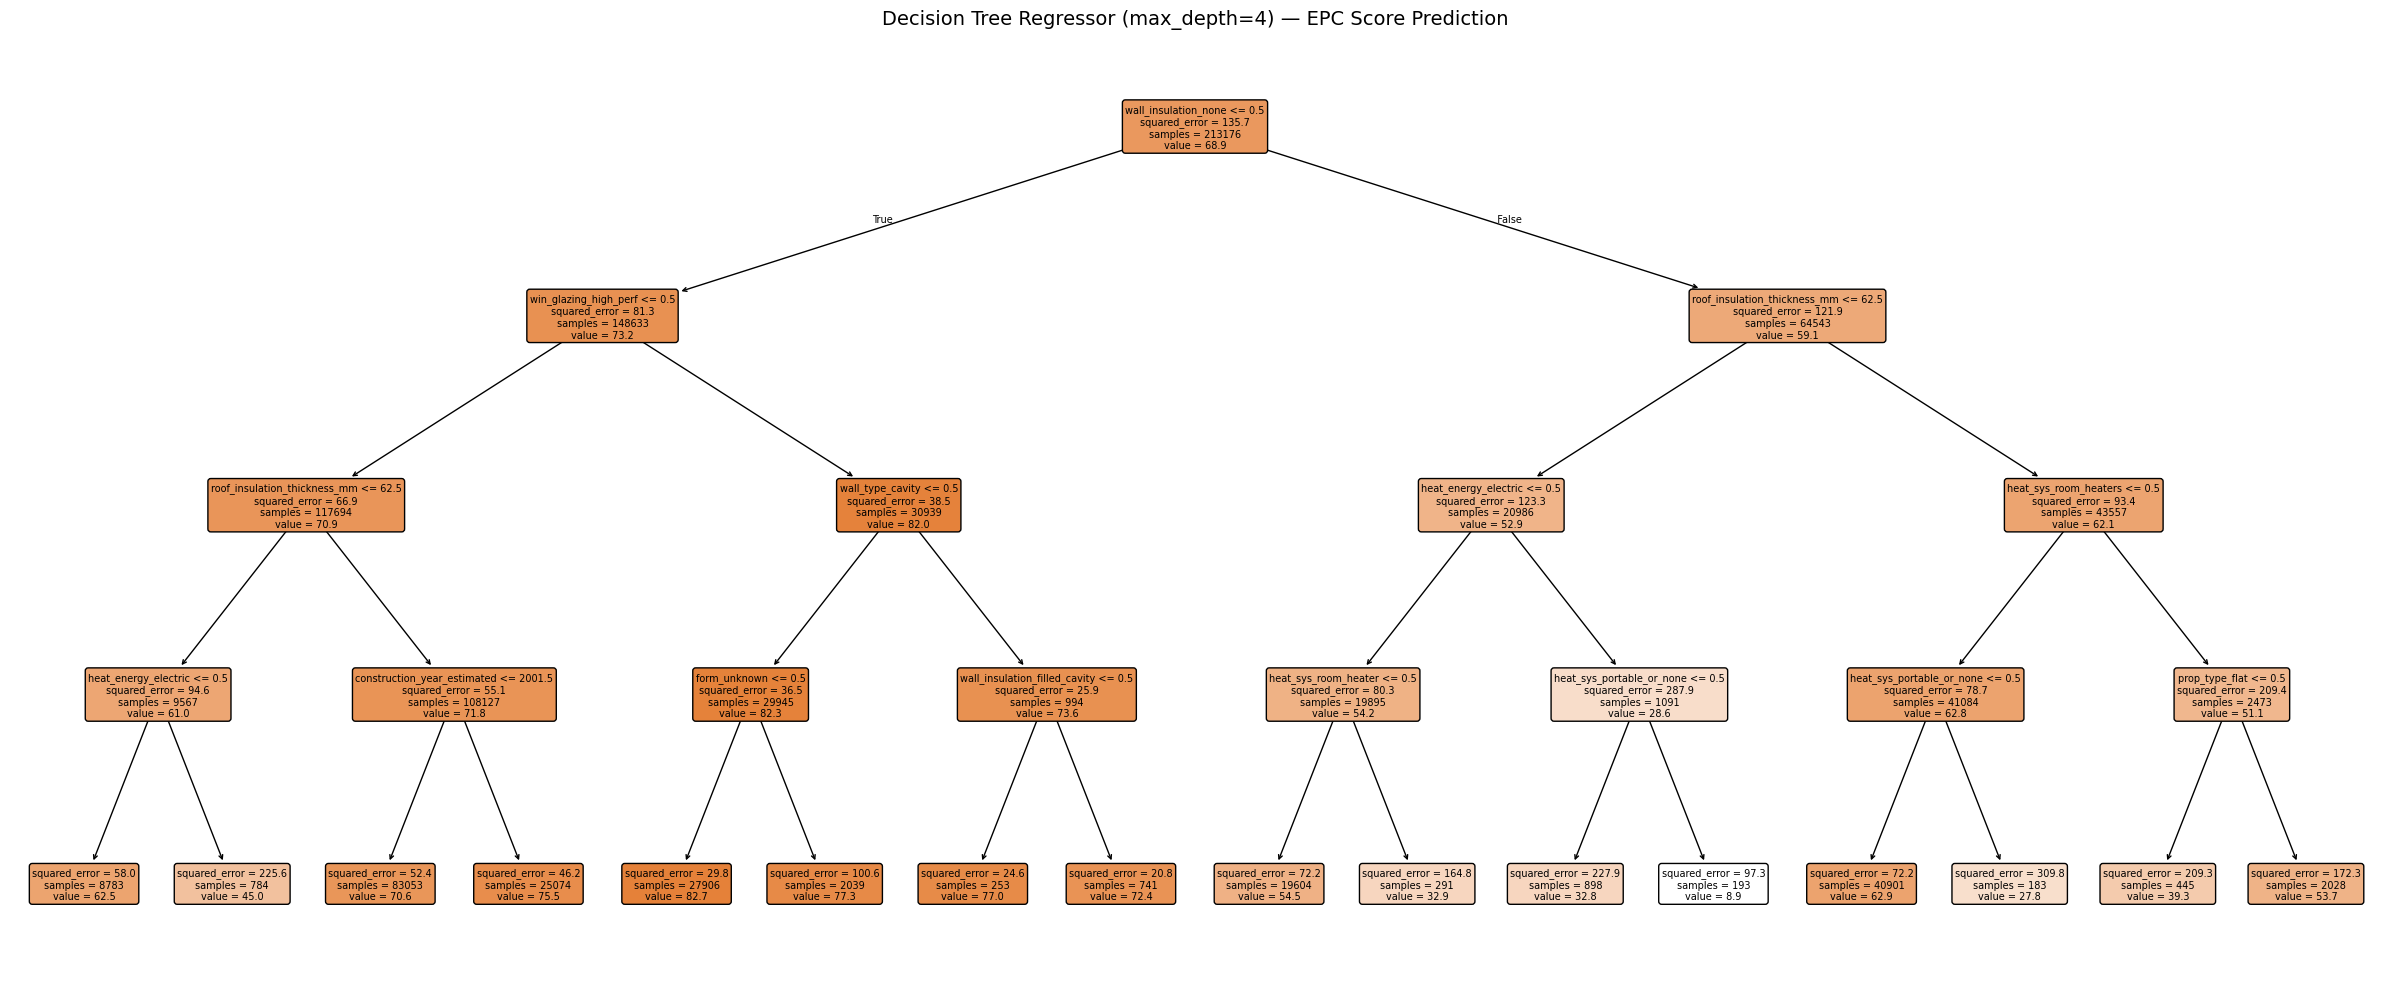


=== TEXT RULES (max_depth=4) ===
|--- wall_insulation_none <= 0.50
|   |--- win_glazing_high_perf <= 0.50
|   |   |--- roof_insulation_thickness_mm <= 62.50
|   |   |   |--- heat_energy_electric <= 0.50
|   |   |   |   |--- value: [62.46]
|   |   |   |--- heat_energy_electric >  0.50
|   |   |   |   |--- value: [45.04]
|   |   |--- roof_insulation_thickness_mm >  62.50
|   |   |   |--- construction_year_estimated <= 2001.50
|   |   |   |   |--- value: [70.65]
|   |   |   |--- construction_year_estimated >  2001.50
|   |   |   |   |--- value: [75.45]
|   |--- win_glazing_high_perf >  0.50
|   |   |--- wall_type_cavity <= 0.50
|   |   |   |--- form_unknown <= 0.50
|   |   |   |   |--- value: [82.65]
|   |   |   |--- form_unknown >  0.50
|   |   |   |   |--- value: [77.26]
|   |   |--- wall_type_cavity >  0.50
|   |   |   |--- wall_insulation_filled_cavity <= 0.50
|   |   |   |   |--- value: [77.04]
|   |   |   |--- wall_insulation_filled_cavity >  0.50
|   |   |   |   |--- value: [72.38

In [137]:
# Tuned tree has max_depth=20 — unreadable when visualised.
# A separate shallow tree (max_depth=4) is trained solely for human-interpretable output.
shallow_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=4, random_state=42))
])
shallow_pipeline.fit(X_train, y_train)

all_feature_names = shallow_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Strip 'num__' / 'cat__' prefixes added by ColumnTransformer for readability
all_feature_names = [name.split('__')[-1] for name in all_feature_names]

# Plot
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    shallow_pipeline.named_steps['model'],
    feature_names=all_feature_names,
    filled=True, rounded=True, fontsize=7,
    impurity=True, precision=1, ax=ax
)
plt.title('Decision Tree Regressor (max_depth=4) — EPC Score Prediction', fontsize=14)
plt.tight_layout()
plt.savefig('dt_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

# Text representation (for report)
print("\n=== TEXT RULES (max_depth=4) ===")
print(export_text(
    shallow_pipeline.named_steps['model'],
    feature_names=all_feature_names,
    max_depth=4
))

## 9. Feature Importance

Feature importances from the **tuned** tree. Tells us which physical building characteristics drive EPC score predictions most.

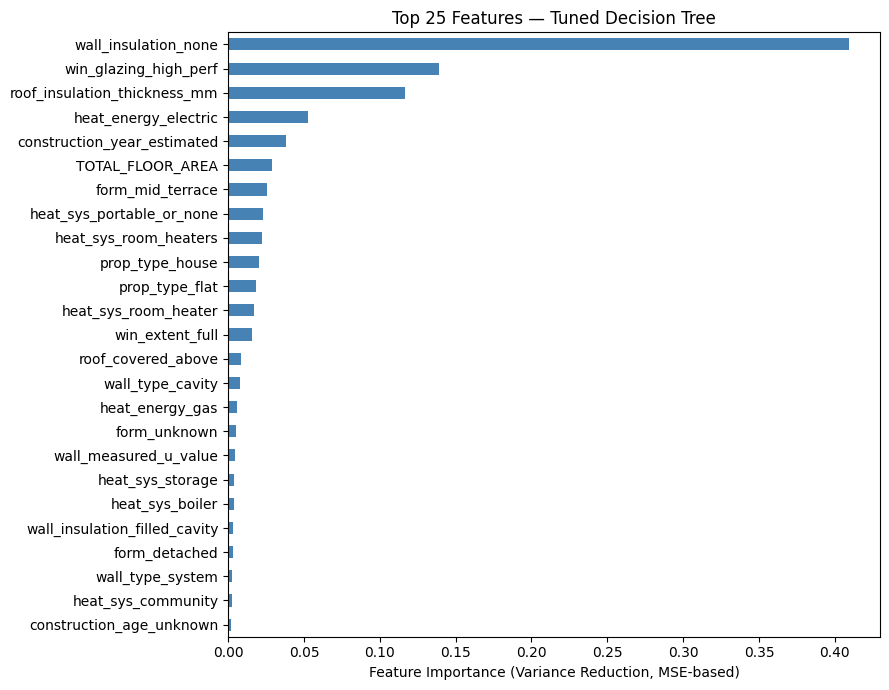

Top 10 features:
wall_insulation_none            0.409368
win_glazing_high_perf           0.139155
roof_insulation_thickness_mm    0.116873
heat_energy_electric            0.052698
construction_year_estimated     0.038163
TOTAL_FLOOR_AREA                0.029174
form_mid_terrace                0.025302
heat_sys_portable_or_none       0.022967
heat_sys_room_heaters           0.022020
prop_type_house                 0.020098


In [138]:
best_dt = grid_search.best_estimator_

all_features_tuned = [name.split('__')[-1] for name in best_dt.named_steps['preprocessor'].get_feature_names_out()]

importances = best_dt.named_steps['model'].feature_importances_
feat_imp = (
    pd.Series(importances, index=all_features_tuned)
    .sort_values(ascending=False)
    .head(25)
)

plt.figure(figsize=(9, 7))
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance (Variance Reduction, MSE-based)')
plt.title('Top 25 Features — Tuned Decision Tree')
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features:")
print(feat_imp.head(10).to_string())

## 10. Summary

Results table for the project report.

In [139]:
import numpy as np
from sklearn.metrics import mean_squared_error

y_test_pred = best_dt.predict(X_test)
y_train_pred = best_dt.predict(X_train)

year_test  = X_test['construction_year_estimated'].copy()
year_train = X_train['construction_year_estimated'].copy()

bins   = [0, 1919, 1944, 1974, 2000, float('inf')]
labels = ['Pre-1919', '1919–1944', '1945–1974', '1975–2000', '2001+']

year_group_test  = pd.cut(year_test,  bins=bins, labels=labels)
year_group_train = pd.cut(year_train, bins=bins, labels=labels)

rows = []
for grp in labels:
    mask_test  = year_group_test  == grp
    mask_train = year_group_train == grp

    test_rmse  = np.sqrt(mean_squared_error(y_test[mask_test],   y_test_pred[mask_test]))   if mask_test.sum()  > 0 else np.nan
    train_rmse = np.sqrt(mean_squared_error(y_train[mask_train], y_train_pred[mask_train])) if mask_train.sum() > 0 else np.nan

    rows.append({
        'Year Group'     : grp,
        'Test n'         : mask_test.sum(),
        'Train RMSE'     : round(train_rmse, 3),
        'Test RMSE'      : round(test_rmse,  3),
        'Gap (overfit?)' : round(test_rmse - train_rmse, 3)
    })

year_rmse_df = pd.DataFrame(rows)
print("=== Construction Year Group Train vs Test RMSE ===")
print(year_rmse_df.to_string(index=False))


dummy_cv_rmse_mean = -dummy_cv_rmse.mean()
dummy_cv_mae_mean  = -dummy_cv_mae.mean()
dt_best_cv_rmse    = -grid_search.best_score_

# GridSearch optimised for RMSE only — rerun CV separately to obtain MAE for the summary table
dt_tuned_cv_mae = cross_val_score(
    best_dt, X_train, y_train,
    cv=10, scoring='neg_mean_absolute_error', n_jobs=-1
)

summary = pd.DataFrame({
    'Model'  : ['Dummy (mean)', 'Decision Tree (default)', 'Decision Tree (tuned)'],
    'CV RMSE': [round(dummy_cv_rmse_mean, 3),
                round(-dt_default_rmse.mean(), 3),
                round(dt_best_cv_rmse, 3)],
    'CV MAE' : [round(dummy_cv_mae_mean, 3),
                round(-dt_default_mae.mean(), 3),
                round(-dt_tuned_cv_mae.mean(), 3)]
})

print("Best params (tuned DT):", grid_search.best_params_)

print("=== PHASE 4 RESULTS SUMMARY (CV-based) ===")
print(summary.to_string(index=False))

summary.to_parquet('phase4_dt_results.parquet', index=False)
print("\nResults saved to phase4_dt_results.parquet")

import joblib

# Save the best model for evaluation in the combined notebook
joblib.dump(best_dt, 'dt_best_model.pkl')

# Save test data so all models share the same split
X_test.to_parquet('x_test.parquet')
y_test.to_frame(name='CURRENT_ENERGY_EFFICIENCY').to_parquet('y_test.parquet')

print("Saved: dt_best_model.pkl, x_test.parquet, y_test.parquet")

=== Construction Year Group Train vs Test RMSE ===
Year Group  Test n  Train RMSE  Test RMSE  Gap (overfit?)
  Pre-1919   12467       6.942      7.304           0.362
 1919–1944    8280       5.690      5.947           0.257
 1945–1974   13799       5.647      5.819           0.172
 1975–2000    8930       5.199      5.526           0.327
     2001+    9818       4.529      4.856           0.327
Best params (tuned DT): {'model__max_depth': 20, 'model__max_features': None, 'model__min_samples_leaf': 10, 'model__min_samples_split': 100}
=== PHASE 4 RESULTS SUMMARY (CV-based) ===
                  Model  CV RMSE  CV MAE
           Dummy (mean)   11.697   8.716
Decision Tree (default)    7.128   4.629
  Decision Tree (tuned)    6.055   4.140

Results saved to phase4_dt_results.parquet
Saved: dt_best_model.pkl, x_test.parquet, y_test.parquet
